# SupportSense — Exploratory Data Analysis

## Business Problem

Digital banking platforms receive large volumes of customer
support queries covering issues such as card payments,
transfers, cash withdrawals and account management.

The objective of SupportSense is to classify incoming
customer messages into the correct support intent so that
queries can be routed more efficiently.

This notebook explores the BANKING77 dataset before model
development.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

In [3]:
DATA_DIR = Path("../data/raw")

train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

In [4]:
train_df.head()

,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


In [6]:
train_df.shape, test_df.shape

((10003, 2), (3080, 2))

In [7]:
train_df.columns

Index(['text', 'category'], dtype='str')

In [8]:
print(f"Training rows: {len(train_df):,}")
print(f"Test rows: {len(test_df):,}")

Training rows: 10,003
Test rows: 3,080


In [9]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   text      10003 non-null  str  
 1   category  10003 non-null  str  
dtypes: str(2)
memory usage: 156.4 KB


In [10]:
train_df.isna().sum()

text        0
category    0
dtype: int64

In [11]:
train_df.duplicated().sum()

np.int64(0)

In [12]:
train_df["category"].nunique()

77

In [13]:
class_counts = train_df["category"].value_counts()

class_counts

category
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
                                                   ... 
lost_or_stolen_card                                  82
card_swallowed                                       61
card_acceptance                                      59
virtual_card_not_working                             41
contactless_not_working                              35
Name: count, Length: 77, dtype: int64

In [14]:
class_counts.describe()

count     77.000000
mean     129.909091
std       32.942207
min       35.000000
25%      112.000000
50%      127.000000
75%      159.000000
max      187.000000
Name: count, dtype: float64

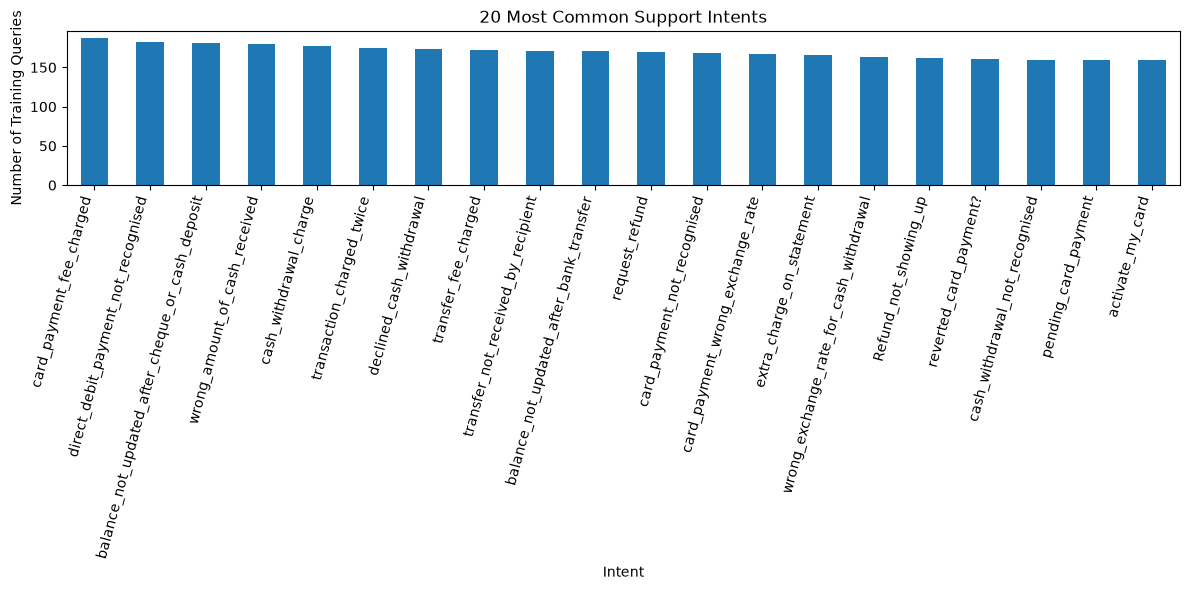

In [15]:
top_classes = class_counts.head(20)

plt.figure(figsize=(12, 6))
top_classes.plot(kind="bar")

plt.title("20 Most Common Support Intents")
plt.xlabel("Intent")
plt.ylabel("Number of Training Queries")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()

plt.show()

## Observation

The classes are fairly balanced
'card_payment_fee_charged' categories occurred most frequently


In [16]:
train_df["character_count"] = (
    train_df["text"].astype(str).str.len()
)

train_df["word_count"] = (
    train_df["text"]
    .astype(str)
    .str.split()
    .str.len()
)

In [17]:
train_df[
    ["character_count", "word_count"]
].describe()

,character_count,word_count
count,10003.000000,10003.000000
mean,59.473758,11.949415
std,40.867901,7.891577
min,13.000000,2.000000
25%,36.000000,7.000000
50%,47.000000,10.000000
75%,64.000000,13.000000
max,433.000000,79.000000


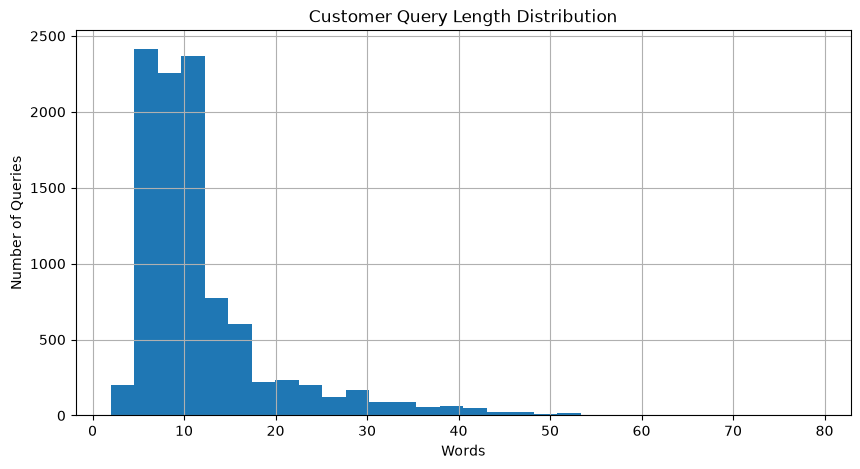

In [18]:
plt.figure(figsize=(10, 5))

train_df["word_count"].hist(bins=30)

plt.title("Customer Query Length Distribution")
plt.xlabel("Words")
plt.ylabel("Number of Queries")

plt.show()

In [19]:
train_df.nsmallest(
    10,
    "word_count"
)[["text", "category", "word_count"]]

,text,category,word_count
2187,Cancel Transaction,cancel_transfer,2
4847,passcode retrieval,passcode_forgotten,2
4889,Lost password,passcode_forgotten,2
5176,pending transaction?,pending_card_payment,2
5561,Transfer declined.,declined_transfer,2
9979,Supported countries,country_support,2
791,withdrawal pending meaning?,pending_cash_withdrawal,3
833,Explain pending transactions.,pending_cash_withdrawal,3
1513,Report stolen card,lost_or_stolen_card,3
2077,Cancel a transaction,cancel_transfer,3


In [20]:
train_df.nlargest(
    10,
    "word_count"
)[["text", "category", "word_count"]]

,text,category,word_count
3917,Hearing back from us regarding your important ...,unable_to_verify_identity,79
7310,Hi! I'm a university student studying abroad a...,transfer_fee_charged,78
3934,Hearing about your verification results from u...,unable_to_verify_identity,75
3905,You will hear back from us about your verifica...,unable_to_verify_identity,70
3910,It can take between 10 minutes to an hour befo...,unable_to_verify_identity,70
5515,Hello-Can you please help me get a refund from...,request_refund,69
7229,"I transferred 7,000 to a receiver outside the ...",transfer_fee_charged,68
6392,My account shows I have been charged twice for...,transaction_charged_twice,66
751,When I used one of the ATMs in the city centre...,pending_cash_withdrawal,64
3637,I think my card is being used by someone else ...,card_payment_not_recognised,64


In [21]:
mean_length = train_df["word_count"].mean()
median_length = train_df["word_count"].median()
std_length = train_df["word_count"].std()

print(f"Mean: {mean_length:.2f}")
print(f"Median: {median_length:.2f}")
print(f"Standard deviation: {std_length:.2f}")

Mean: 11.95
Median: 10.00
Standard deviation: 7.89


In [22]:
test_df["word_count"] = (
    test_df["text"]
    .astype(str)
    .str.split()
    .str.len()
)

print(
    "Train mean:",
    train_df["word_count"].mean()
)

print(
    "Test mean:",
    test_df["word_count"].mean()
)

Train mean: 11.949415175447365
Test mean: 10.952597402597403


In [23]:
train_categories = set(train_df["category"])
test_categories = set(test_df["category"])

print(
    "Categories missing from test:",
    train_categories - test_categories
)

print(
    "Categories only in test:",
    test_categories - train_categories
)

Categories missing from test: set()
Categories only in test: set()
